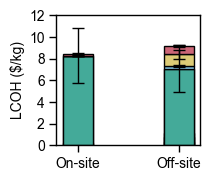

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rc('font',family='Arial')


# Labels and components
labels = ['On-site', 'Off-site']
components = ['Production', 'Compression', 'Delivery', 'Storage']
colors = ['#44AA99', '#88CCEE', '#DDCC77', '#CC6677']  # Add color for compression (light red)

# Updated means and uncertainty ranges for 4 components
means = np.array([
    [8.26, 0.00, 0.00, 0.17],   # On-site: only production, rest zero
    [7, 0.3, 1.1, 0.75]      # Off-site: all components
])





#6.19, 5.14, 7.24

low = np.array([
    [5.74, 0.00, 0.00, 0.07],
    [4.9, 0.2, 0.7, 0.65]
])

high = np.array([
    [10.78, 0.00, 0.00, 0.27],
    [9.23, 0.4, 1.5, 0.85]
])
yerr = np.array([(means - low).T, (high - means).T])



# Plot
fig, ax = plt.subplots(figsize=(2.20315, 1.913386))
bar_width = 0.15
x = [0, 0.5]  # or try [0, 0.6] or [0, 0.7] to adjust
bottoms = np.zeros(len(labels))





for i, component in enumerate(components):
    bar = ax.bar(x, means[:, i], bar_width, label=component,
                 bottom=bottoms, color=colors[i], edgecolor='black')
    
    # Add error bars
for i, component in enumerate(components):
    for j in range(len(labels)):
        # Draw segment
        ax.bar(x[j], means[j,
               i], bar_width,
               bottom=bottoms[j], color=colors[i], edgecolor='black', linewidth = 1.0)

        # Plot error bar at the TOP of the segment
        top = bottoms[j] + means[j, i]
        err_low = means[j, i] - low[j, i]
        err_high = high[j, i] - means[j, i]
        
        ax.errorbar(x[j], top,
                    yerr=[[err_low], [err_high]],
                    fmt='none', ecolor='black', capsize=4, linewidth=1.0)

        # Update bottom after plotting
        bottoms[j] = top
# Aesthetics
ax.set_ylabel('LCOH ($/kg)', fontsize = 10, labelpad=3)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks(range(0, 14, 2))
#ax.set_ylim(bottom = 0, top = 9)

patches = [mpatches.Patch(facecolor=color, label=label, edgecolor='black', linewidth=1) 
           for color, label in zip(colors, components)]
# 
# ax.legend(
#     handles=patches,
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.25),
#     ncol=4,
#     handlelength=1.2,   # shorter handle
#     handleheight=0.8,   # slightly smaller slot height
#     handletextpad=0.4,  # much less space between box and text
#     columnspacing=0.8,  # tighter columns
#     fontsize=10,
#     frameon=False,
# )


ax.tick_params(axis='both', which='major', labelsize=10, width=1, length=5)
# set the axis line width in pixels
for axis in 'left', 'bottom', 'top', 'right':
  ax.spines[axis].set_linewidth(1.0)


#x = np.arange(len(labels))

#ax.set_facecolor('xkcd:salmon')
#ax.set_facecolor((0.97, 0.93, 0.86))

#ax.set_title('Contributions to LCOH with Uncertainty')
plt.savefig('onsite vs offsite h2.svg', dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [2]:
# Carbon intensity vs LCOH

C:\Users\hwadg\AppData\Local\Temp\ipykernel_53368\1852904285.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


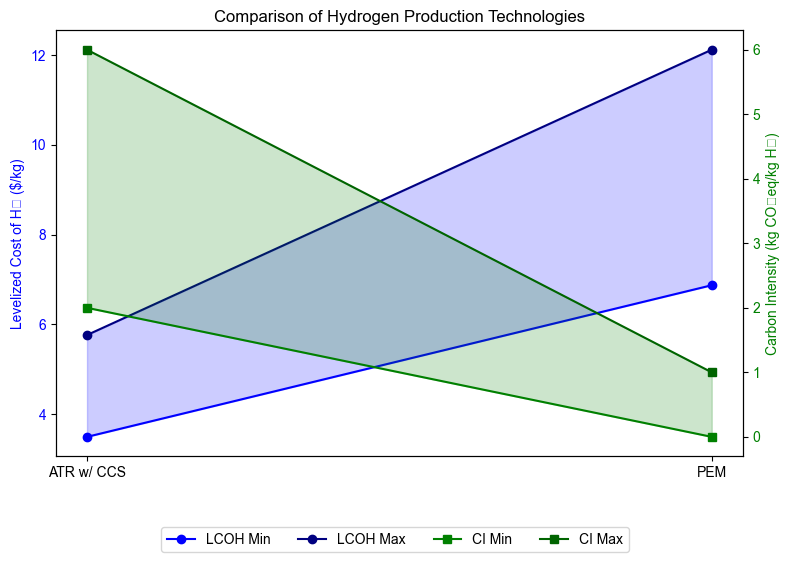

In [3]:
import matplotlib.pyplot as plt

# X-axis categories
technologies = ['ATR w/ CCS', 'PEM']
x = range(len(technologies))

# LCOH values (left y-axis)
lcoh_min = [3.49, 6.87]
lcoh_max = [5.76, 12.12]

# CI values (right y-axis)
ci_min = [2, 0]
ci_max = [6, 1]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot LCOH on left axis
ax1.plot(x, lcoh_min, label='LCOH Min', marker='o', color='blue')
ax1.plot(x, lcoh_max, label='LCOH Max', marker='o', color='navy')
ax1.fill_between(x, lcoh_min, lcoh_max, color='blue', alpha=0.2)
ax1.set_ylabel('Levelized Cost of H₂ ($/kg)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Twin axis for CI
ax2 = ax1.twinx()
ax2.plot(x, ci_min, label='CI Min', marker='s', color='green')
ax2.plot(x, ci_max, label='CI Max', marker='s', color='darkgreen')
ax2.fill_between(x, ci_min, ci_max, color='green', alpha=0.2)
ax2.set_ylabel('Carbon Intensity (kg CO₂eq/kg H₂)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# X-axis ticks and labels
plt.xticks(x, technologies)

# Titles and legend
plt.title('Comparison of Hydrogen Production Technologies')
fig.tight_layout()
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4)

plt.show()

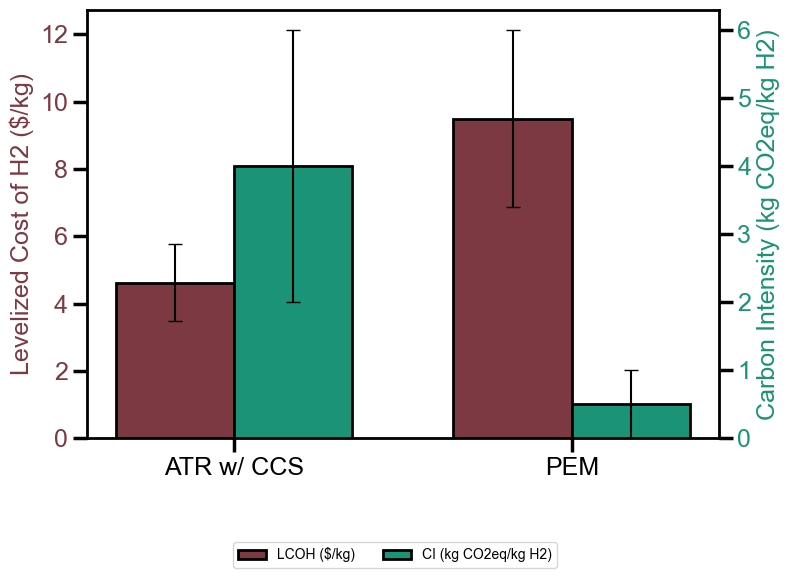

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font',family='Arial')


# Categories
technologies = ['ATR w/ CCS', 'PEM']
x = np.arange(len(technologies))

# LCOH data ($/kg H2)
lcoh_min = np.array([3.49, 6.87])
lcoh_max = np.array([5.76, 12.12])
lcoh_avg = (lcoh_min + lcoh_max) / 2
lcoh_err = (lcoh_max - lcoh_min) / 2

# CI data (kg CO2eq/kg H2)
ci_min = np.array([2, 0])
ci_max = np.array([6, 1])
ci_avg = (ci_min + ci_max) / 2
ci_err = (ci_max - ci_min) / 2

# Plotting
fig, ax1 = plt.subplots(figsize=(8, 5))
width = 0.35

# LCOH bars (left y-axis)
bar1 = ax1.bar(x - width/2, lcoh_avg, width, yerr=lcoh_err,
               capsize=5, label='LCOH ($/kg)', color='#7c3942', edgecolor='black',
           linewidth=2.0)
ax1.set_ylabel('Levelized Cost of H2 ($/kg)', color='#7c3942', fontsize = 18)
ax1.tick_params(axis='y', labelcolor='#7c3942')
ax1.set_xticks(x)
ax1.set_xticklabels(technologies, fontsize = 18)

# CI bars (right y-axis)
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, ci_avg, width, yerr=ci_err,
               capsize=5, label='CI (kg CO2eq/kg H2)', color='#1b9376', edgecolor='black',
           linewidth=2.0)
ax2.set_ylabel('Carbon Intensity (kg CO2eq/kg H2)', color='#1b9376', fontsize = 18)
ax2.tick_params(axis='y', labelcolor='#1b9376')


for axis in 'left', 'bottom', 'top', 'right':
  ax1.spines[axis].set_linewidth(2.0)
ax1.tick_params(axis='both', which='major', labelsize=18, width=2.5, length=10)
ax2.tick_params(axis='both', which='major', labelsize=18, width=2.5, length=10)



# Title and legend
#plt.title('Hydrogen Production: Cost and Carbon Intensity Comparison')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2)
fig.tight_layout()
plt.savefig('econvsenvironmentalh2.png', dpi=300, bbox_inches='tight')

plt.show()


In [5]:
57.5*2*24

2760.0

In [6]:
# For example (replace with your real data if needed):
saf_min = [2.1, 2.3, 2.7, 3.1]
saf_max = [3.4, 3.8, 4.1, 4.5]

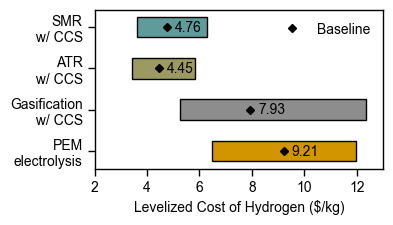

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font',family='Arial')


# Data
routes = ['SMR\n w/ CCS', 'ATR\n w/ CCS', 'Gasification\n w/ CCS', 'PEM\nelectrolysis']
min_vals = np.array([3.63, 3.42, 5.25, 6.48])
baseline = np.array([4.76, 4.45, 7.93, 9.21])
max_vals = np.array([6.27, 5.84, 12.36, 11.96])
colors = ['#5F9B9B', '#9B9B61', '#8D8D8D', '#D29500']

# Calculate widths and centers for thick bars
bar_thickness = 0.3
y_pos = np.linspace(0, len(routes) - 1, len(routes)) * 0.6  # 20% closer

# Plot setup
fig, ax = plt.subplots(figsize=(4.0315, 2.35472441))

# Draw thick horizontal bars for min–max range
for i in range(len(routes)):
    ax.barh(y=y_pos[i],
            width=max_vals[i] - min_vals[i],
            left=min_vals[i],
            height=bar_thickness,
            color=colors[i],
            edgecolor='black',
           linewidth=1.0)

# Plot diamond markers for baseline
ax.plot(baseline, y_pos, marker='D', color='black', linestyle='None', markersize=4, label='Baseline')

# Aesthetics
ax.set_yticks(y_pos)
ax.set_yticklabels(routes, fontsize=10)
#for label in ax.get_yticklabels():
#    label.set_va('center')  # Ensures vertical alignment is center
#    label.set_ha('center')  # Optional: center horizontally too

#ax.tick_params(axis='y', pad=50)  # adds horizontal space between ticks and labels

ax.set_xlabel('Levelized Cost of Hydrogen ($/kg)', fontsize=10)
ax.set_xlim(2, 13)
ax.invert_yaxis()  # Optional: top-to-bottom
#ax.grid(True, axis='x', linestyle='--', alpha=0.5)
#ax.tick_params(axis='x', labelsize=12)

ax.tick_params(axis='both', which='major', labelsize=10, width=1, length=5)
# set the axis line width in pixels
for axis in 'left', 'bottom', 'top', 'right':
  ax.spines[axis].set_linewidth(1.0)



# Add value labels
for i, val in enumerate(baseline):
    ax.text(val + 0.3, y_pos[i], f'{val:.2f}', va='center', fontsize=10)

# Legend
ax.legend(loc='upper right', fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('hydrogen cost range.svg', dpi=500, bbox_inches='tight')
plt.show()

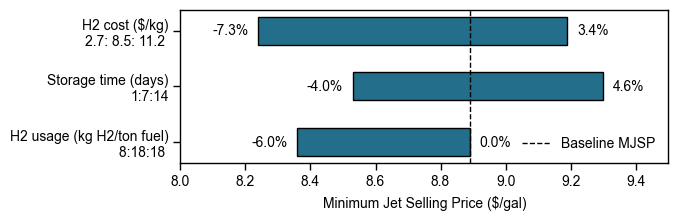

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Reordered data (H2 cost first)
parameters = ['H2 cost ($/kg)\n2.7: 8.5: 11.2 ',
              'Storage time (days)\n1:7:14',
              'H2 usage (kg H2/ton fuel)\n8:18:18 ']

mjsp_low     = np.array([8.24, 8.53, 8.36])
mjsp_baseline= np.array([8.89, 8.89, 8.89])
mjsp_high    = np.array([9.19, 9.30,8.89])





# Setup bar parameters
param_range = np.array(mjsp_high - mjsp_low)
y_pos = np.linspace(0, len(parameters) - 1, len(parameters)) * 0.8
bar_thickness = 0.4



# Plot
fig, ax = plt.subplots(figsize=(6.8815, 2.313386))

# Horizontal bars (Low to High MJSP)
for i in range(len(parameters)):
    ax.barh(y=y_pos[i],
            width=mjsp_high[i] - mjsp_low[i],
            left=mjsp_low[i],
            height=bar_thickness,
            color='#236F8B',
            edgecolor='black',
            linewidth=1)

# Baseline vertical line
ax.axvline(x=8.89, color='black', linestyle='--', linewidth=1, label='Baseline MJSP')

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(parameters, fontsize=10)
ax.set_xlabel('Minimum Jet Selling Price ($/gal)', fontsize=10, labelpad=5)
ax.set_xlim(8, 9.5)
#ax.tick_params(axis='x', labelsize=20)
#ax.tick_params(axis='y', labelsize=20)
#ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.invert_yaxis() 

ax.tick_params(axis='both', which='major', labelsize=10, width=1.0, length=5)
# set the axis line width in pixels
for axis in 'left', 'bottom', 'top', 'right':
  ax.spines[axis].set_linewidth(1.0)

for i in range(len(parameters)):
    # Percent difference from baseline
    pct_low = (mjsp_low[i] - mjsp_baseline[i]) / mjsp_baseline[i] * 100
    pct_high = (mjsp_high[i] - mjsp_baseline[i]) / mjsp_baseline[i] * 100

    ax.text(mjsp_low[i] - 0.03, y_pos[i],
            f"{pct_low:.1f}%", va='center', ha='right', fontsize=10)
    ax.text(mjsp_high[i] + 0.03, y_pos[i],
            f"{pct_high:.1f}%", va='center', ha='left', fontsize=10)

# Legend
ax.legend(loc='lower right', fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("MJSP_sensitivity_analysis.svg", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\hwadg\AppData\Local\Temp\ipykernel_53368\3431057040.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


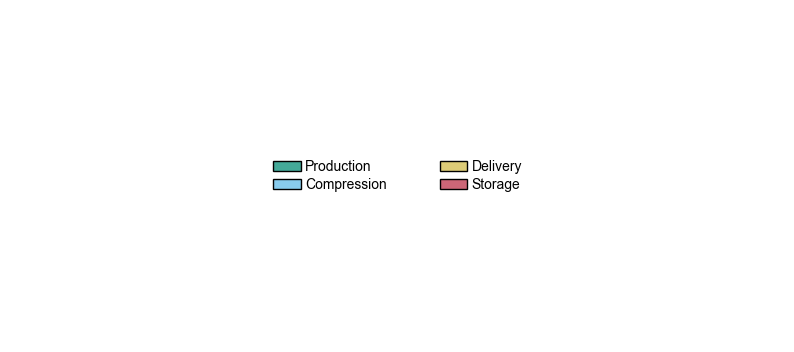

In [12]:
# Code that provides a legend for the breakdown
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rc('font',family='Arial')
# Define categories and corresponding colors from original vertical legend
categories_styled =  ['Production', 'Compression', 'Delivery', 'Storage']


colors_styled = ['#44AA99', '#88CCEE', '#DDCC77', '#CC6677']  # Add color for compression (light red)




patches = [mpatches.Patch(facecolor=color, label=label, edgecolor='black', linewidth=1) 
           for color, label in zip(colors_styled, categories_styled)]

fig, ax = plt.subplots(figsize=(10, 2))

# Create legend
legend = ax.legend(
    handles=patches,
    loc='center',
    ncol=2,
    frameon=False,        # No frame around the entire legend
    fontsize=10,
    handlelength=2,
    handletextpad=0.3,
    borderpad=10.8,
    columnspacing=3.8,
    labelspacing=0.3
)

# Ensure no text boxes
for text in legend.get_texts():
    text.set_bbox(None)

ax.axis('off')
plt.tight_layout()
plt.savefig("legend h2.svg")
plt.show()